# From embeddings to scverse SpatialData

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CraigMyles/raw2features/blob/main/notebooks/04_spatialdata.ipynb)

**What you'll do:** take a raw2features `.embeddings.zarr`, run `raw2features export-spatialdata` to convert it into a scverse [SpatialData](https://spatialdata.scverse.org) `.zarr`, then load it and inspect the `tiles` shapes + the `obsm["X_resnet50"]` embeddings table - finishing with a map of the patch tiles **coloured by an embedding component**.

This is a pure *post-hoc conversion*: no model is run here, no GPU, no Hugging Face token, no download. It runs top-to-bottom on a plain CPU in seconds. The SpatialData export needs the optional **`[spatialdata]`** extra (handled by the bootstrap cell below).

## 0. Bootstrap (Colab / local)

Detects the runtime and installs `raw2features` only where it isn't already present. Colab has no repo checkout, so we `pip install` from PyPI; a local editable install already has it (so we skip). Note the extras include **`spatialdata`** - that's what makes `export-spatialdata` work.

In [1]:
import importlib.util, subprocess, sys

IN_COLAB = "google.colab" in sys.modules
HAVE_PKG = importlib.util.find_spec("raw2features") is not None

# SpatialData export needs the [spatialdata] extra (spatialdata + geopandas) on top of
# the resnet50 stack. After a PyPI release prefer a hard pin: raw2features[...]==0.2.0
EXTRAS = "zarr,image,torch,models,spatialdata"
SPEC = f"raw2features[{EXTRAS}]"  # PyPI; pin a version (==0.2.0) for reproducibility

if IN_COLAB or not HAVE_PKG:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", SPEC])

# Record the exact environment (Ten Simple Rules: pin + report).
import raw2features, numpy, zarr, spatialdata
print("raw2features", raw2features.__version__)
print("python", sys.version.split()[0],
      "| numpy", numpy.__version__,
      "| zarr", zarr.__version__,
      "| spatialdata", spatialdata.__version__,
      "| colab" if IN_COLAB else "| local")

raw2features 0.1.0
python 3.12.3 | numpy 2.4.6 | zarr 3.2.1 | spatialdata 0.7.3 | local


## 1. Get an embedding store to convert

The exporter *consumes an existing store* - it never recomputes embeddings. To keep this notebook self-contained and offline we generate a tiny synthetic OME-NGFF slide and embed it with **resnet50** (open / ungated / CPU-fine). If you already have a `.embeddings.zarr` from an earlier notebook or a real slide, point `STORE` at it instead and skip this cell.

`raw2features sample` writes a synthetic slide (no download/token/GPU); `embed -m resnet50 --device auto` picks cuda/mps/cpu automatically and lands on CPU here. The result is a SPEC-conformant store with `coords`, `grid_index`, `mask`, `features/resnet50`, and a self-describing provenance header.

In [2]:
import subprocess

# Synthetic slide -> embeddings store. Both run on CPU in seconds.
subprocess.check_call(["raw2features", "sample", "sample.ome.zarr", "--size", "3072"])
subprocess.check_call(
    ["raw2features", "embed", "sample.ome.zarr", "out/",
     "-m", "resnet50", "--mpp", "0.5", "--device", "auto"]
)

STORE = "out/sample.embeddings.zarr"
subprocess.check_call(["raw2features", "validate-store", STORE])
print("embedding store ready:", STORE)

wrote synthetic OME-Zarr slide: sample.ome.zarr
try:  raw2features embed sample.ome.zarr out/ -m resnet50 --device auto


slide_id: sample
status: complete
grids: {'mpp0.5_px224': ['resnet50']}
output_uri: file:///home/user/raw2features/out/sample.embeddings.zarr
per_grid: [{'slide_id': 'sample', 'status': 'complete', 'n_patches': 90, 'models': ['resnet50'], 'models_added': ['resnet50'], 'models_skipped': [], 'slide_embeddings': {}, 'output_uri': 'file:///home/user/raw2features/out/sample.embeddings.zarr', 'geojson': None, 'thumbnail': None, 'elapsed_s': 2.35}]
elapsed_s: 2.9


OK - conforms to embeddings-store spec v0.1
embedding store ready: out/sample.embeddings.zarr


## 2. Export to SpatialData

One command converts the store into a scverse SpatialData `.zarr`. By default it writes a sibling `sample.spatialdata.zarr` next to the input, exports **every** model present (here just `resnet50`), and authors one **square polygon per patch** (`--geometry polygon`; pass `--geometry circle` for the HEST/Visium "spot" convention instead).

The export is a bridge, not a recompute, so there is no FAIR loss or duplication: The full provenance header (per-model licence, model card, segmentation, patching, source URI) is carried straight into `uns["raw2features"]`, and the WSI pyramid is *referenced* via its source URI rather than copied - so the SpatialData store stays small and the embeddings remain traceable to the exact model weights and read plan that produced them.

In [3]:
out = subprocess.run(
    ["raw2features", "export-spatialdata", STORE, "--overwrite"],
    check=True, capture_output=True, text=True,
)
SDATA_PATH = out.stdout.strip()  # the CLI prints the output path
print("SpatialData store:", SDATA_PATH)

SpatialData store: /home/user/raw2features/out/sample.spatialdata.zarr


## 3. Load it back and inspect the structure

The store is plain OME-NGFF-aligned SpatialData, so `spatialdata.read_zarr` opens it directly - readable by squidpy, napari-spatialdata, and scanpy. Two elements matter:

- **`shapes["tiles"]`** - a GeoDataFrame, one square polygon per patch, in **level-0 (full-res) pixel** coordinates under an `Identity` transform in the `global` coordinate system. These are faithful patch footprints, not arbitrary points.
- **`tables["table"]`** - an AnnData with one row per tile, linked to `tiles` by `region`/`instance_id`.

In [4]:
import spatialdata

sdata = spatialdata.read_zarr(SDATA_PATH)
print(sdata)

tiles = sdata.shapes["tiles"]
print("\ntiles:", type(tiles).__name__, "| n =", len(tiles),
      "| geometry:", sorted(tiles.geometry.geom_type.unique()))
print(tiles.head())

SpatialData object, with associated Zarr store: /home/user/raw2features/out/sample.spatialdata.zarr
├── Shapes
│     └── 'tiles': GeoDataFrame shape: (90, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (90, 0)
with coordinate systems:
    ▸ 'global', with elements:
        tiles (Shapes)
    ▸ 'micrometers', with elements:
        tiles (Shapes)

tiles: GeoDataFrame | n = 90 | geometry: ['Polygon']
                                            geometry
0  POLYGON ((1344 224, 1344 448, 1120 448, 1120 2...
1  POLYGON ((1568 224, 1568 448, 1344 448, 1344 2...
2  POLYGON ((1792 224, 1792 448, 1568 448, 1568 2...
3  POLYGON ((2016 224, 2016 448, 1792 448, 1792 2...
4  POLYGON ((1120 448, 1120 672, 896 672, 896 448...


## 4. The embeddings table

The deliverable lives in `obsm`:

- `obsm["X_resnet50"]` - the `(N, dim)` patch embedding, `float32` (one `X_<model>` per exported model). `X` itself is intentionally empty (`n_var = 0`) - embeddings belong in `obsm`, not in the expression matrix.
- `obsm["spatial"]` - `(N, 2)` tile **centres** in full-res pixels (the squidpy / HEST convention; this is what `to_legacy_anndata` reconstructs from).
- `obs` - `x`, `y` (level-0 top-left px, CLAM/Trident convention), `array_row`/`array_col` (grid position), `level`, `mpp`, `tissue_frac`, plus the `region`/`instance_id` link columns.

The `mpp` column records the **achieved microns-per-pixel** of the read - the exact-MPP read plan that produced these patches travels with the data, so a downstream consumer knows the physical scale without guessing.

In [5]:
import numpy as np

table = sdata.tables["table"]
print(table)

X = np.asarray(table.obsm["X_resnet50"])      # (N, dim) float32
xy = np.asarray(table.obsm["spatial"])         # (N, 2) tile centres, full-res px
print("\nX_resnet50:", X.shape, X.dtype, "| spatial:", xy.shape)
print("obs columns:", list(table.obs.columns))
print(table.obs[["x", "y", "array_row", "array_col", "mpp"]].to_string())

AnnData object with n_obs × n_vars = 90 × 0
    obs: 'x', 'y', 'level', 'mpp', 'array_row', 'array_col', 'tissue_frac', 'region', 'instance_id'
    uns: 'raw2features', 'spatialdata_attrs', 'raw2features_export'
    obsm: 'X_resnet50', 'spatial'

X_resnet50: (90, 2048) float32 | spatial: (90, 2)
obs columns: ['x', 'y', 'level', 'mpp', 'array_row', 'array_col', 'tissue_frac', 'region', 'instance_id']
              x     y  array_row  array_col  mpp
tile_id                                         
1120_0224  1120   224          1          5  0.5
1344_0224  1344   224          1          6  0.5
1568_0224  1568   224          1          7  0.5
1792_0224  1792   224          1          8  0.5
0896_0448   896   448          2          4  0.5
1120_0448  1120   448          2          5  0.5
1344_0448  1344   448          2          6  0.5
1568_0448  1568   448          2          7  0.5
1792_0448  1792   448          2          8  0.5
2016_0448  2016   448          2          9  0.5
0672_0672

## 5. Reduce the embedding to one component

To colour the tiles by "what the encoder saw", we project each patch's 2048-D resnet50 vector onto its **first principal component** (PC1). We do this with a plain NumPy SVD - no scikit-learn, fully deterministic, CPU-only. PC1 is just an illustrative scalar per tile; in a real analysis you'd cluster the embeddings, run UMAP, or correlate them with labels.

In [6]:
# Centre, then project onto the top right-singular vector (= PC1).
Xc = X.astype(np.float64) - X.mean(axis=0, keepdims=True)
Vt = np.linalg.svd(Xc, full_matrices=False)[2]
pc1 = Xc @ Vt[0]                               # (N,) one scalar per tile
print("PC1 per tile:", np.round(pc1, 3))

PC1 per tile: [ -9.089  -5.294  -7.332 -10.211  -1.207   4.529   4.442   4.014   1.707
  -6.996  -4.954   4.835   4.972   4.596   1.717   0.484  -0.179  -5.247
  -0.233   4.38    3.21    0.563   1.501   0.303   0.912  -2.835  -7.366
   4.682   4.569   1.648  -0.539   4.577   3.77    2.967   1.782  -9.906
  -5.256   4.48    4.805   3.709   3.669   4.19    2.566   3.251   3.533
  -7.727  -5.443   4.962   1.231   1.475   1.085   2.405   1.783   0.899
   4.006  -8.415  -5.942   3.424   0.212   0.066   0.633   0.211   0.993
   2.005   1.684  -2.205   3.06    3.761   2.146   2.584   2.426   2.059
  -5.285  -4.729   4.296   4.628   4.184   1.656   0.518  -3.504  -8.274
  -2.53    2.273   4.394   2.16   -2.182  -7.993  -8.74   -6.342  -7.628]


## 6. Visualise: tiles coloured by the embedding component

The `[spatialdata]` extra ships `spatialdata` + `geopandas` (not a plotting library), so the **guaranteed** visualisation below uses matplotlib via the tiles' GeoDataFrame - it works with nothing beyond what we already installed.

We join the per-tile PC1 value back onto the polygons by **`instance_id`** (the table↔shapes link recorded in `uns["spatialdata_attrs"]`), not by row position - that's the robust, order-independent way SpatialData relates a table to its shapes. We flip the y-axis so the picture matches image/pixel convention (y grows downward).

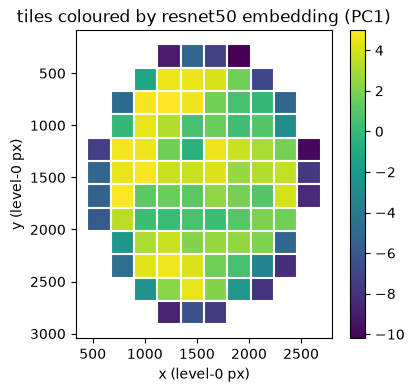

In [7]:
import matplotlib.pyplot as plt

# Map each tile (its GeoDataFrame index == instance_id) to its PC1 value.
val_by_instance = dict(zip(np.asarray(table.obs["instance_id"]).tolist(), pc1.tolist()))
gdf = tiles.copy()
gdf["pc1"] = [val_by_instance[i] for i in gdf.index]

fig, ax = plt.subplots(figsize=(4.5, 4))
gdf.plot(column="pc1", ax=ax, cmap="viridis",
         edgecolor="white", linewidth=1.5, legend=True)
ax.set_aspect("equal")
ax.invert_yaxis()                              # image convention: y downward
ax.set_xlabel("x (level-0 px)")
ax.set_ylabel("y (level-0 px)")
ax.set_title("tiles coloured by resnet50 embedding (PC1)")
plt.show()

## 7. (Optional) The same view via `spatialdata-plot` / squidpy

`spatialdata-plot` and `squidpy` are **not** part of the `[spatialdata]` extra, so this cell installs them on demand. It's a convenience - the matplotlib view above is the canonical, dependency-light one. To colour shapes by a value, `spatialdata-plot` expects the value as a column on the table, so we copy PC1 onto `obs` first. We pin `coordinate_systems="global"` (pixel space) so it draws a single panel matching the view above - the store also carries a `micrometers` system, and without pinning `pl.show` renders one subplot per system. The cell is wrapped so a failed/slow install never breaks the notebook's top-to-bottom run.

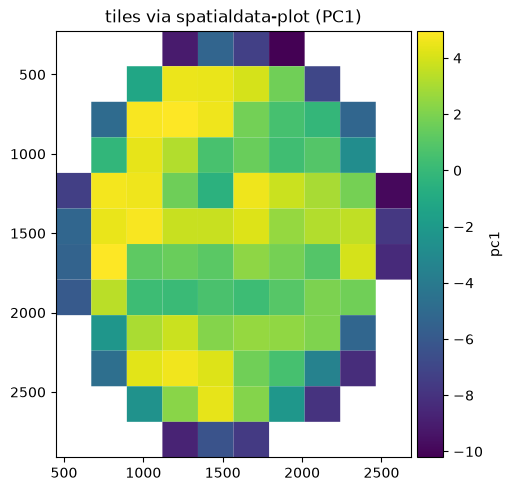

In [8]:
try:
    if importlib.util.find_spec("spatialdata_plot") is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "spatialdata-plot"])
    import spatialdata_plot  # noqa: F401  (registers the .pl accessor on sdata)

    # spatialdata-plot colours shapes from a table column -> stash PC1 on obs.
    table.obs["pc1"] = pc1.astype("float32")
    # The store carries two coordinate systems (global = level-0 pixels, micrometers);
    # pin one so pl.show draws a single panel matching the view above, not one per system.
    (
        sdata.pl.render_shapes("tiles", color="pc1", cmap="viridis")
        .pl.show(coordinate_systems="global", title="tiles via spatialdata-plot (PC1)")
    )
except Exception as exc:  # install failure / offline / API drift - non-fatal
    print("Optional spatialdata-plot view skipped:", type(exc).__name__, exc)
    print("The matplotlib view in the previous cell is the canonical one.")

## Next steps

- **Round-trip to plain AnnData** for scanpy/squidpy neighbourhood analyses: `spatialdata_io.experimental.to_legacy_anndata(sdata)` reconstructs a Visium-style AnnData from `obsm["spatial"]`.
- **Multiple models / circles:** `raw2features export-spatialdata STORE --model uni --model conch --geometry circle` exports several encoders at once (each as `obsm["X_<model>"]`).
- **Real spatial analysis:** cluster `obsm["X_resnet50"]` (e.g. k-means / Leiden), build a spatial neighbours graph with squidpy on `obsm["spatial"]`, and test for spatial autocorrelation - the tile centres and physical `mpp` are already in the store.
- **Other bridges:** see `docs/INTEROP.md` for the pathology-MIL HDF5 export (`export-h5`, TRIDENT/CLAM/TITAN and STAMP layouts) and QuPath GeoJSON tiles.
- **Provenance:** everything you need to cite the exact weights and read plan is in `sdata.tables["table"].uns["raw2features"]` (model DOI, weights SHA-256, pinned HF revision, segmentation, source URI).

---
**[raw2features](https://github.com/CraigMyles/raw2features)** · OME-Zarr WSIs → foundation-model embeddings · author **Craig Myles** · licence **MIT**

If you use raw2features, please cite it ([`CITATION.cff`](https://github.com/CraigMyles/raw2features/blob/main/CITATION.cff)). Pretrained encoders carry their own licences ([`MODEL_LICENSES.md`](https://github.com/CraigMyles/raw2features/blob/main/docs/MODEL_LICENSES.md)).